In [ ]:
# 예제 3-1

import cv2 as cv
import sys

img=cv.imread('/Users/pitzsb1/computer-vision-practice/ch3/soccer.jpg')

if img is None:
    sys.exit("Could not read the image.")

cv.imshow('Title', img)
#cv.imshow('Upper left half', img[0:img.shape[0]//2, 0:img.shape[1]//2, :])
#cv.imshow('Center', img[img.shape[0]//4:img.shape[0]*3//4, img.shape[1]//4:img.shape[1]*3//4, :])
cv.imshow('Red channel', img[0:img.shape[0]//2,0:img.shape[1]//2,2])
cv.imshow('Green channel', img[:img.shape[0]//2,0:img.shape[1]//2,1])
cv.imshow('Blue channel', img[:img.shape[0]//2,0:img.shape[1]//2,0])


cv.waitKey()
cv.destroyAllWindows()

In [5]:
# 예제 3-3

import cv2 as cv
import sys

img=cv.imread('/Users/pitzsb1/computer-vision-practice/ch3/soccer.jpg') 
            
t,bin_img=cv.threshold(img[:,:,2],0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
print('오츄 알고리즘이 찾은 최적 임곗값=',t)

cv.imshow('R channel',img[:,:,2])			# R 채널 영상
cv.imshow('R channel binarization',bin_img)	# R 채널 이진화 영상

cv.waitKey()
cv.destroyAllWindows()

오츄 알고리즘이 찾은 최적 임곗값= 113.0


In [6]:
# 예제 3-5

import cv2 as cv
import numpy as np

img=cv.imread('/Users/pitzsb1/computer-vision-practice/ch3/soccer.jpg') 
img=cv.resize(img,dsize=(0,0),fx=0.25,fy=0.25)

def gamma(f,gamma=1.0):
    f1=f/255.0			# L=256이라고 가정
    return np.uint8(255*(f1**gamma))

gc=np.hstack((gamma(img,0.5),gamma(img,0.75),gamma(img,1.0),gamma(img,2.0),gamma(img,3.0)))
cv.imshow('gamma',gc)

cv.waitKey()
cv.destroyAllWindows()

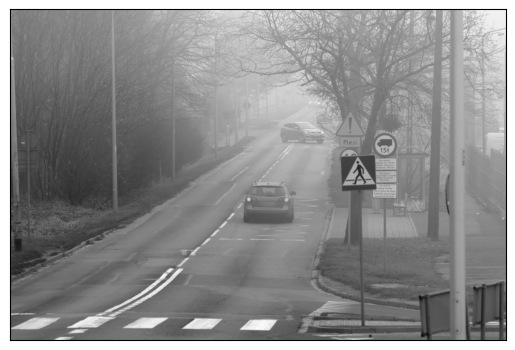

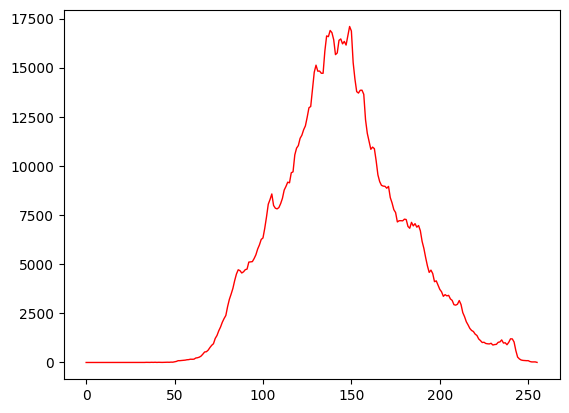

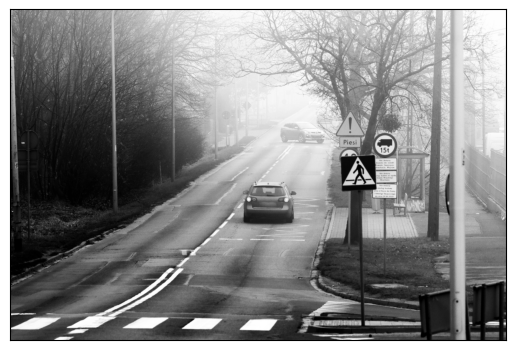

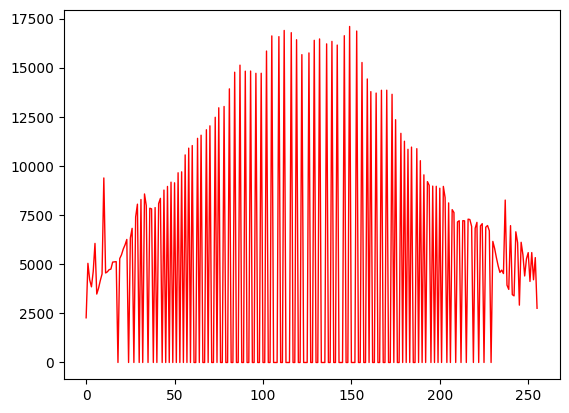

([<matplotlib.lines.Line2D at 0x17f3fb4d0>], None)

In [7]:
# 예제 3-6

import cv2 as cv
import matplotlib.pyplot as plt

img=cv.imread('/Users/pitzsb1/computer-vision-practice/ch3/mistyroad.jpg') 

gray=cv.cvtColor(img,cv.COLOR_BGR2GRAY)		# 명암 영상으로 변환하고 출력
plt.imshow(gray,cmap='gray'), plt.xticks([]), plt.yticks([]), plt.show()

h=cv.calcHist([gray],[0],None,[256],[0,256])	# 히스토그램을 구해 출력
plt.plot(h,color='r',linewidth=1), plt.show()

equal=cv.equalizeHist(gray)			# 히스토그램을 평활화하고 출력
plt.imshow(equal,cmap='gray'), plt.xticks([]), plt.yticks([]), plt.show()

h=cv.calcHist([equal],[0],None,[256],[0,256])	# 히스토그램을 구해 출력
plt.plot(h,color='r',linewidth=1), plt.show()

In [8]:
# 예제 3-8

import cv2 as cv

img=cv.imread('/Users/pitzsb1/computer-vision-practice/ch3/rose.png')
patch=img[250:350,170:270,:]

img=cv.rectangle(img,(170,250),(270,350),(255,0,0),3)
patch1=cv.resize(patch,dsize=(0,0),fx=5,fy=5,interpolation=cv.INTER_NEAREST)
patch2=cv.resize(patch,dsize=(0,0),fx=5,fy=5,interpolation=cv.INTER_LINEAR)
patch3=cv.resize(patch,dsize=(0,0),fx=5,fy=5,interpolation=cv.INTER_CUBIC)

cv.imshow('Original',img)
cv.imshow('Resize nearest',patch1) 
cv.imshow('Resize bilinear',patch2) 
cv.imshow('Resize bicubic',patch3) 

cv.waitKey()
cv.destroyAllWindows()

In [9]:
# 0915 과제

import cv2 as cv

img=cv.imread('/Users/pitzsb1/computer-vision-practice/ch3/rose.png')
patch=img[250:350,170:270,:]

def draw(event, x, y, flags, param):
    if event == cv.EVENT_LBUTTONDOWN:
        # 왼쪽 클릭 → 빨간색 직사각형
        cv.rectangle(img, (x, y), (x+200, y+200), (0, 0, 255), 2)

    cv.imshow('Drawing', img)

cv.namedWindow('Drawing')
cv.imshow('Drawing', img)

cv.setMouseCallback('Drawing', draw)

while True:
    if cv.waitKey(1) == ord('q'):
        cv.destroyAllWindows()
        break

KeyboardInterrupt: 